In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, Polygon


df = pd.read_pickle("/content/normalized_data.pkl")


In [ ]:

import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
from sklearn.model_selection import train_test_split

# Define a custom dataset class
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Define the features we will use
feature_columns = ['latitude', 'longitude', 'VV_soil', 'VH_soil', 'NDVI', 'NDMI', 'B1', 'B10',
       'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9',
       'landsat_NDVI',
       'landsat_NDMI', 'landsat_B1', 'landsat_B2', 'landsat_B3', 'landsat_B4', 'landsat_B5',
       'landsat_B6', 'landsat_B7', 'landsat_B8', 'landsat_B9', 'landsat_B10', 'landsat_B11',
       'DSM']

# Define the label we will use
target_column = 'soil_moisture'

shuffled_df = df.sample(frac=1).reset_index(drop=True)
features = shuffled_df[feature_columns]
target = shuffled_df[target_column]

In [ ]:
for column in feature_columns:
    shuffled_df[column] = pd.to_numeric(shuffled_df[column], errors='coerce')

# Handle missing values, for example, by filling with 0 or column mean
shuffled_df.dropna()

,station,datetime,soil_moisture,latitude,longitude,VV,VH,angle,NDVI,NDMI,...,landsat_B6,landsat_B7,landsat_B8,landsat_B9,landsat_B10,landsat_B11,DSM,koppen_class,VV_soil,VH_soil
0,BOULDER-14-W,2017-06-08 01:00:00,0.2050,0.040035,-0.105541,-15.848536,-21.057725,0.587876,0.554370,0.095198,...,0.075331,0.475868,0.075331,0.475868,0.276428,0.276863,0.584844,0.19,0.046605,-1.000000
1,ELKINS-21-ENE,2018-10-13 23:00:00,0.3720,0.039013,-0.079474,-10.514795,-19.222698,0.050420,0.373502,-0.027746,...,0.223926,0.231261,0.223926,0.231261,0.282969,0.282710,-0.545332,0.09,0.198983,0.000352
2,SKYMOUNTAIN,2019-07-03 13:00:00,0.1100,0.039224,-0.106908,-12.095173,-17.192058,0.406958,0.689063,0.162829,...,0.202822,0.309466,0.202822,0.309466,0.301986,0.300366,0.391069,0.19,0.176663,0.047662
3,RILEY-10-WSW,2020-06-02 14:00:00,0.1360,0.043471,-0.119692,-12.487664,-22.391330,0.050957,0.134044,-0.146453,...,0.252719,0.204664,0.252719,0.204664,0.317638,0.315969,-0.282815,0.05,0.132952,-0.101105
4,WHITMAN-5-ENE,2023-11-12 00:00:00,0.0830,0.042068,-0.101445,-16.816972,-26.782489,0.817651,0.159375,-0.255767,...,0.295358,0.195656,0.295358,0.195656,0.285284,0.285312,-0.410555,0.25,0.031442,-0.205158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183159,SOD130,2017-09-19 15:00:00,0.0610,0.067257,0.026749,-11.961761,-14.631907,0.664365,0.444325,0.071060,...,0.073152,0.323561,0.073152,0.323561,0.246809,0.248251,-0.900406,0.19,0.172386,0.146083
183160,ElCoto,2018-11-06 06:00:00,0.0430,0.041381,-0.005429,-10.225433,-16.870600,0.286841,0.134220,-0.171037,...,0.370667,0.361448,0.370667,0.361448,0.295722,0.294899,-0.602706,0.11,0.186885,0.030758
183161,2.11,2018-12-16 17:00:00,0.3182,0.055970,0.009023,-12.283237,-16.848899,-0.769005,0.272447,0.057317,...,0.195773,0.175381,0.195773,0.175381,0.291052,0.290251,-0.975643,0.09,0.145671,0.046926
183162,SAA111,2016-05-12 04:00:00,0.3450,0.068330,0.027551,-11.905146,-17.546975,-0.873266,-0.080375,0.937726,...,0.148510,0.341062,0.148510,0.341062,0.278892,0.278661,-0.753721,0.19,0.143582,0.007852


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_pickle("/content/normalized_data.pkl")

feature_columns = [
    'latitude','longitude','VV_soil','VH_soil','NDVI','NDMI',
    'B1','B10','B11','B12','B2','B3','B4','B5','B6','B7','B8','B8A','B9',
    'landsat_NDVI','landsat_NDMI',
    'landsat_B1','landsat_B2','landsat_B3','landsat_B4',
    'landsat_B5','landsat_B6','landsat_B7','landsat_B8',
    'landsat_B9','landsat_B10','landsat_B11',
    'DSM'
]

target_column = 'soil_moisture'

# Convert to numeric
for col in feature_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[target_column] = pd.to_numeric(df[target_column], errors='coerce')

# Drop missing values
df = df.dropna().reset_index(drop=True)

X = df[feature_columns].values.astype(np.float32)
y = df[target_column].values.astype(np.float32)

print(X.shape, y.shape)


(183164, 33) (183164,)


In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_list, bias_list, rmse_list, ubrmse_list = [], [], [], []

for train_idx, val_idx in tqdm(kf.split(X), total=5, desc="RF 5-Fold CV"):
    X_train_cv, X_val_cv = X[train_idx], X[val_idx]
    y_train_cv, y_val_cv = y[train_idx], y[val_idx]

    rf_model = RandomForestRegressor(
        n_estimators=50,        # 🔥 reduced
        max_depth=20,           # 🔥 reduced
        min_samples_leaf=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )

    rf_model.fit(X_train_cv, y_train_cv)
    y_pred = rf_model.predict(X_val_cv)

    bias = np.mean(y_pred - y_val_cv)
    rmse = np.sqrt(mean_squared_error(y_val_cv, y_pred))
    r2 = r2_score(y_val_cv, y_pred)
    ubrmse = np.sqrt(np.mean((y_pred - y_val_cv - bias) ** 2))

    r2_list.append(r2)
    bias_list.append(bias)
    rmse_list.append(rmse)
    ubrmse_list.append(ubrmse)

print("\n✅ Random Forest Average Accuracy (5-Fold CV)")
print(f"R²     : {np.mean(r2_list):.4f}")
print(f"Bias   : {np.mean(bias_list):.4f}")
print(f"RMSE   : {np.mean(rmse_list):.4f}")
print(f"ubRMSE : {np.mean(ubrmse_list):.4f}")


RF 5-Fold CV: 100%|██████████| 5/5 [01:34<00:00, 18.94s/it]


✅ Random Forest Average Accuracy (5-Fold CV)
R²     : 0.7662
Bias   : 0.0001
RMSE   : 0.0517
ubRMSE : 0.0517


In [ ]:
import os
import joblib

# Create directory if it doesn't exist
os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/rf_model.pkl")
print("📌 Model saved!")


📌 Model saved!


In [ ]:
import numpy as np
import torch
!pip install pytorch-tabnet
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# === Scale X ===
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

# === Scale y ===
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_list, rmse_list, bias_list, ubrmse_list = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
    print(f"\n📂 Fold {fold+1}")

    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_scaled[train_idx], y_scaled[val_idx]

    tabnet_model = TabNetRegressor(
        n_d=64,
        n_a=64,
        n_steps=4,
        gamma=1.3,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=0.02),
        verbose=0
    )

    tabnet_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric=['rmse'],
        max_epochs=200,
        patience=30,
        batch_size=2048,
        virtual_batch_size=256,
        num_workers=0,
        drop_last=False
    )

    y_pred = tabnet_model.predict(X_val)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_true = y_scaler.inverse_transform(y_val)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    bias = np.mean(y_pred - y_true)
    ubrmse = np.sqrt(np.mean((y_pred - y_true - bias)**2))

    r2_list.append(r2)
    rmse_list.append(rmse)
    bias_list.append(bias)
    ubrmse_list.append(ubrmse)

    print(f" R²: {r2:.4f}, RMSE: {rmse:.4f}, Bias: {bias:.4f}, ubRMSE: {ubrmse:.4f}")

print("\n✅ Final 5-Fold Cross-Validation Results")
print(f"Average R²: {np.mean(r2_list):.4f}")
print(f"Average RMSE: {np.mean(rmse_list):.4f}")
print(f"Average Bias: {np.mean(bias_list):.4f}")
print(f"Average ubRMSE: {np.mean(ubrmse_list):.4f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.7 MB/s eta 0:00:00

📂 Fold 1

Early stopping occurred at epoch 196 with best_epoch = 166 and best_val_0_rmse = 0.49435


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


 R²: 0.7566, RMSE: 0.0529, Bias: 0.0009, ubRMSE: 0.0528

📂 Fold 2
Stop training because you reached max_epochs = 200 with best_epoch = 194 and best_val_0_rmse = 0.48397


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


 R²: 0.7660, RMSE: 0.0517, Bias: 0.0009, ubRMSE: 0.0517

📂 Fold 3

Early stopping occurred at epoch 196 with best_epoch = 166 and best_val_0_rmse = 0.50874


...

 R²: 0.7409, RMSE: 0.0544, Bias: -0.0014, ubRMSE: 0.0544

📂 Fold 4
Stop training because you reached max_epochs = 200 with best_epoch = 194 and best_val_0_rmse = 0.48995


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


 R²: 0.7598, RMSE: 0.0524, Bias: -0.0019, ubRMSE: 0.0523

📂 Fold 5
Stop training because you reached max_epochs = 200 with best_epoch = 197 and best_val_0_rmse = 0.48433


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


 R²: 0.7645, RMSE: 0.0518, Bias: -0.0016, ubRMSE: 0.0518

✅ Final 5-Fold Cross-Validation Results
Average R²: 0.7576
Average RMSE: 0.0526
Average Bias: -0.0006
Average ubRMSE: 0.0526


In [ ]:

joblib.dump(y_scaler, "models/tabnet_target_scaler.pkl")
print("📌 TabNet model and scaler saved!")


Successfully saved model at models/tabnet_model.zip
📌 TabNet model and scaler saved!


In [ ]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# Data
# ===============================
X = shuffled_df[feature_columns].values.astype(np.float32)
y = shuffled_df[target_column].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# Base XGBoost model
# ===============================
xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# ===============================
# REALISTIC hyperparameter grid
# ===============================
param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [8, 12],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.7],
    "colsample_bytree": [0.7]
}

# ===============================
# 5-Fold Grid Search
# ===============================
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("✅ Best parameters found:")
print(grid_search.best_params_)

# ===============================
# Evaluation
# ===============================
best_xgb = grid_search.best_estimator_

y_pred = best_xgb.predict(X_test)

bias = np.mean(y_pred - y_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
ubrmse = np.sqrt(np.mean((y_pred - y_test - bias) ** 2))

print("\n✅ XGBoost Final Evaluation on Held-Out Test Set")
print(f" R²:      {r2:.4f}")
print(f" Bias:    {bias:.4f}")
print(f" RMSE:    {rmse:.4f}")
print(f" ubRMSE:  {ubrmse:.4f}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best parameters found:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 600, 'subsample': 0.7}

✅ XGBoost Final Evaluation on Held-Out Test Set
 R²:      0.7689
 Bias:    -0.0003
 RMSE:    0.0514
 ubRMSE:  0.0514


In [ ]:
joblib.dump(best_xgb, "models/xgb_model.pkl")
print("📌 Model saved!")

📌 Model saved!


✅ All models loaded successfully


[I 2026-02-09 08:29:48,847] A new study created in memory with name: no-name-46921a14-bb3d-4811-8a72-cd9068e02d2a
[I 2026-02-09 08:29:58,882] Trial 0 finished with value: 0.06876545647204002 and parameters: {'tabnet_weight': 0.45321108375070307, 'rf_weight': 0.6011309722670878, 'xgb_weight': 0.02415996282923949}. Best is trial 0 with value: 0.06876545647204002.
[I 2026-02-09 08:30:06,036] Trial 1 finished with value: 0.05277559247444727 and parameters: {'tabnet_weight': 0.38741267822764835, 'rf_weight': 0.6087104934114812, 'xgb_weight': 0.8278674418264742}. Best is trial 1 with value: 0.05277559247444727.
[I 2026-02-09 08:30:13,364] Trial 2 finished with value: 0.05873707937369471 and parameters: {'tabnet_weight': 0.7979600085162285, 'rf_weight': 0.9410444276564923, 'xgb_weight': 0.9120617946316735}. Best is trial 1 with value: 0.05277559247444727.
[I 2026-02-09 08:30:19,959] Trial 3 finished with value: 0.045265546987448835 and parameters: {'tabnet_weight': 0.052872271205897436, 'rf_w


✅ Best Normalized Ensemble Weights
 tabnet_weight: 0.0005
 rf_weight: 0.4227
 xgb_weight: 0.5767

📊 Ensemble Model Metrics
 R²      : 0.7913
 Bias    : -0.0003
 RMSE    : 0.0488
 ubRMSE  : 0.0488
 Pearson : 0.8907


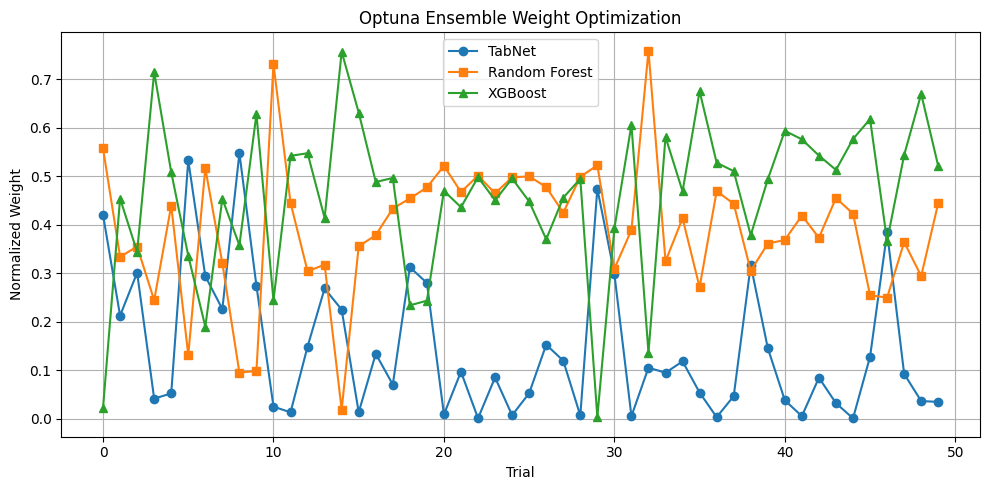

In [ ]:
# =====================================================
# 1. Imports
# =====================================================
import numpy as np
import joblib
import optuna
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

from pytorch_tabnet.tab_model import TabNetRegressor

# ---- TabNet ----
tabnet_model = TabNetRegressor()
tabnet_model.load_model("models/tabnet_model.zip")

target_scaler = joblib.load("models/tabnet_target_scaler.pkl")

# ---- Random Forest ----
rf_model = joblib.load("models/rf_model.pkl")

# ---- XGBoost ----
xgb_model = joblib.load("models/xgb_model.pkl")

print("✅ All models loaded successfully")

# =====================================================
# 4. Train / Validation / Test split
# =====================================================
X_ens, X_test, y_ens, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_ens = y_ens.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# =====================================================
# 5. Evaluation function
# =====================================================
def evaluate_model(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    ubrmse = np.sqrt(np.mean((y_pred - y_true - bias) ** 2))
    pearson, _ = pearsonr(y_true.flatten(), y_pred.flatten())

    print(f"\n📊 {name} Metrics")
    print(f" R²      : {r2:.4f}")
    print(f" Bias    : {bias:.4f}")
    print(f" RMSE    : {rmse:.4f}")
    print(f" ubRMSE  : {ubrmse:.4f}")
    print(f" Pearson : {pearson:.4f}")

# =====================================================
# 6. Optuna objective (NO CV → NO LEAKAGE)
# =====================================================
def objective(trial):

    w_tabnet = trial.suggest_float("tabnet_weight", 0.0, 1.0)
    w_rf = trial.suggest_float("rf_weight", 0.0, 1.0)
    w_xgb = trial.suggest_float("xgb_weight", 0.0, 1.0)

    total = w_tabnet + w_rf + w_xgb
    w_tabnet /= total
    w_rf /= total
    w_xgb /= total

    # Predictions
    with torch.no_grad():
        tabnet_pred = tabnet_model.predict(X_ens)
    tabnet_pred = target_scaler.inverse_transform(tabnet_pred)

    rf_pred = rf_model.predict(X_ens).reshape(-1, 1)
    xgb_pred = xgb_model.predict(X_ens).reshape(-1, 1)

    ensemble_pred = (
        w_tabnet * tabnet_pred +
        w_rf * rf_pred +
        w_xgb * xgb_pred
    )

    rmse = np.sqrt(mean_squared_error(y_ens, ensemble_pred))
    return rmse

# =====================================================
# 7. Run Optuna
# =====================================================
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

best_weights = study.best_params
total = sum(best_weights.values())
best_weights = {k: v / total for k, v in best_weights.items()}

print("\n✅ Best Normalized Ensemble Weights")
for k, v in best_weights.items():
    print(f" {k}: {v:.4f}")

# =====================================================
# 8. Final Ensemble Evaluation (TEST SET)
# =====================================================
with torch.no_grad():
    tabnet_test = tabnet_model.predict(X_test)
tabnet_test = target_scaler.inverse_transform(tabnet_test)

rf_test = rf_model.predict(X_test).reshape(-1, 1)
xgb_test = xgb_model.predict(X_test).reshape(-1, 1)

ensemble_test = (
    best_weights["tabnet_weight"] * tabnet_test +
    best_weights["rf_weight"] * rf_test +
    best_weights["xgb_weight"] * xgb_test
)

evaluate_model(y_test, ensemble_test, "Ensemble Model")

# =====================================================
# 9. Plot weight evolution
# =====================================================
tab_w, rf_w, xgb_w = [], [], []

for t in study.trials:
    if t.state.name == "COMPLETE":
        total = t.params["tabnet_weight"] + t.params["rf_weight"] + t.params["xgb_weight"]
        tab_w.append(t.params["tabnet_weight"] / total)
        rf_w.append(t.params["rf_weight"] / total)
        xgb_w.append(t.params["xgb_weight"] / total)

plt.figure(figsize=(10, 5))
plt.plot(tab_w, label="TabNet", marker="o")
plt.plot(rf_w, label="Random Forest", marker="s")
plt.plot(xgb_w, label="XGBoost", marker="^")
plt.xlabel("Trial")
plt.ylabel("Normalized Weight")
plt.title("Optuna Ensemble Weight Optimization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import torch
import joblib

from sklearn.metrics import mean_squared_error, r2_score
from pytorch_tabnet.tab_model import TabNetRegressor

# =====================================================
# 1. Load models correctly
# =====================================================

# ---- TabNet (DO NOT use joblib) ----
tabnet_model = TabNetRegressor()
tabnet_model.load_model("models/tabnet_model.zip")

# ---- Target scaler ----
target_scaler = joblib.load("models/tabnet_target_scaler.pkl")

# ---- Random Forest ----
rf_model = joblib.load("models/rf_model.pkl")

# ---- XGBoost ----
xgb_model = joblib.load("models/xgb_model.pkl")

print("✅ All models loaded successfully")

# =====================================================
# 2. Generate predictions
# =====================================================

with torch.no_grad():
    tabnet_preds_test = tabnet_model.predict(X_test)

tabnet_preds_test = target_scaler.inverse_transform(tabnet_preds_test).reshape(-1, 1)
rf_preds_test = rf_model.predict(X_test).reshape(-1, 1)
xgb_preds_test = xgb_model.predict(X_test).reshape(-1, 1)

y_true_test = y_test.reshape(-1, 1)

# =====================================================
# 3. Fixed ensemble weights (normalized)
# =====================================================

weights = {
    "rf": 0.56,
    "tabnet": 0.43,
    "xgb": 0.26
}

total_weight = sum(weights.values())
weights = {k: v / total_weight for k, v in weights.items()}

print("\n✅ Normalized Ensemble Weights:")
for k, v in weights.items():
    print(f" {k}: {v:.4f}")

# =====================================================
# 4. Ensemble prediction
# =====================================================

ensemble_preds_test = (
    weights["rf"] * rf_preds_test +
    weights["tabnet"] * tabnet_preds_test +
    weights["xgb"] * xgb_preds_test
)

# =====================================================
# 5. Metrics
# =====================================================

def compute_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    bias = np.mean(y_pred - y_true)
    ubrmse = np.sqrt(np.mean((y_pred - y_true - bias) ** 2))

    print("\n✅ Ensemble Metrics (Fixed Weights)")
    print(f" R²     : {r2:.4f}")
    print(f" Bias   : {bias:.4f}")
    print(f" RMSE   : {rmse:.4f}")
    print(f" ubRMSE : {ubrmse:.4f}")

    return {"r2": r2, "bias": bias, "rmse": rmse, "ubrmse": ubrmse}

metrics = compute_metrics(y_true_test, ensemble_preds_test)


✅ All models loaded successfully

✅ Normalized Ensemble Weights:
 rf: 0.4480
 tabnet: 0.3440
 xgb: 0.2080

✅ Ensemble Metrics (Fixed Weights)
 R²     : 0.6466
 Bias   : -0.0168
 RMSE   : 0.0635
 ubRMSE : 0.0612



📊 TabNet
R²:     -0.3285
Bias:   -0.0485
RMSE:   0.1231
ubRMSE: 0.1132
Pearson:-0.1596


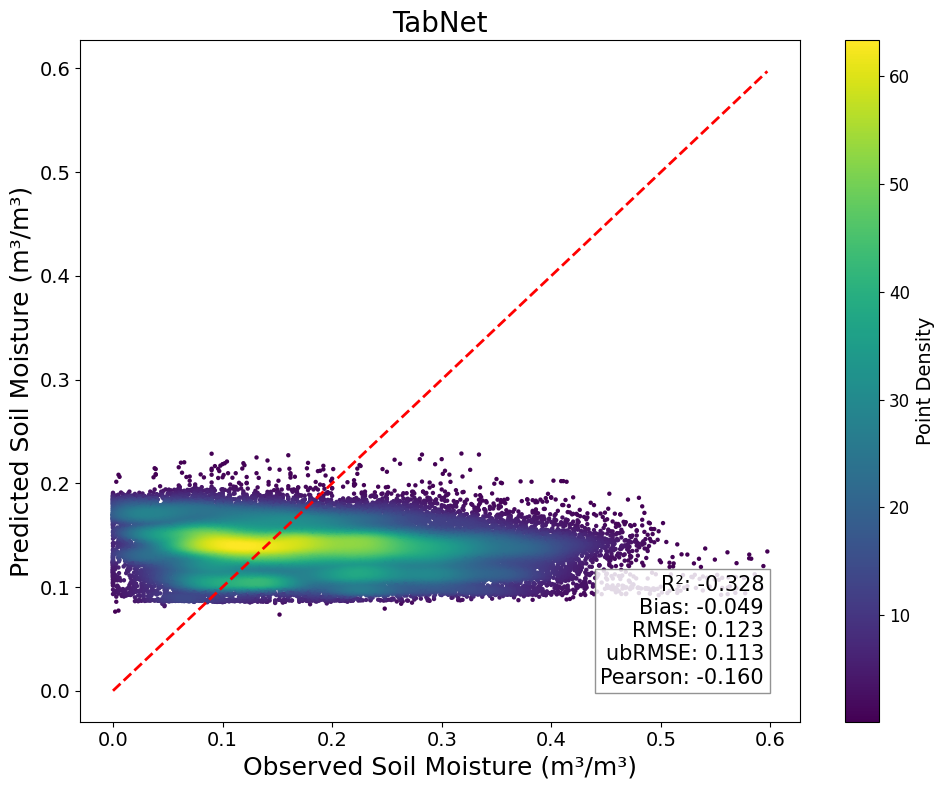


📊 Random Forest
R²:     0.8095
Bias:   -0.0002
RMSE:   0.0466
ubRMSE: 0.0466
Pearson:0.9020


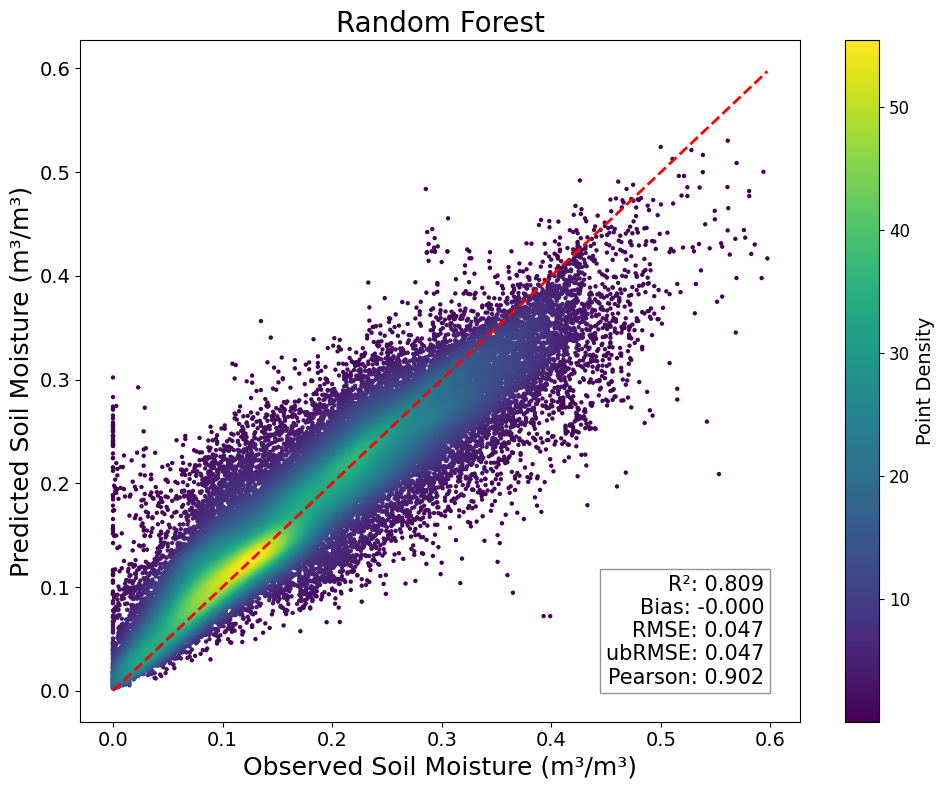


📊 XGBoost
R²:     0.7689
Bias:   -0.0003
RMSE:   0.0514
ubRMSE: 0.0514
Pearson:0.8771


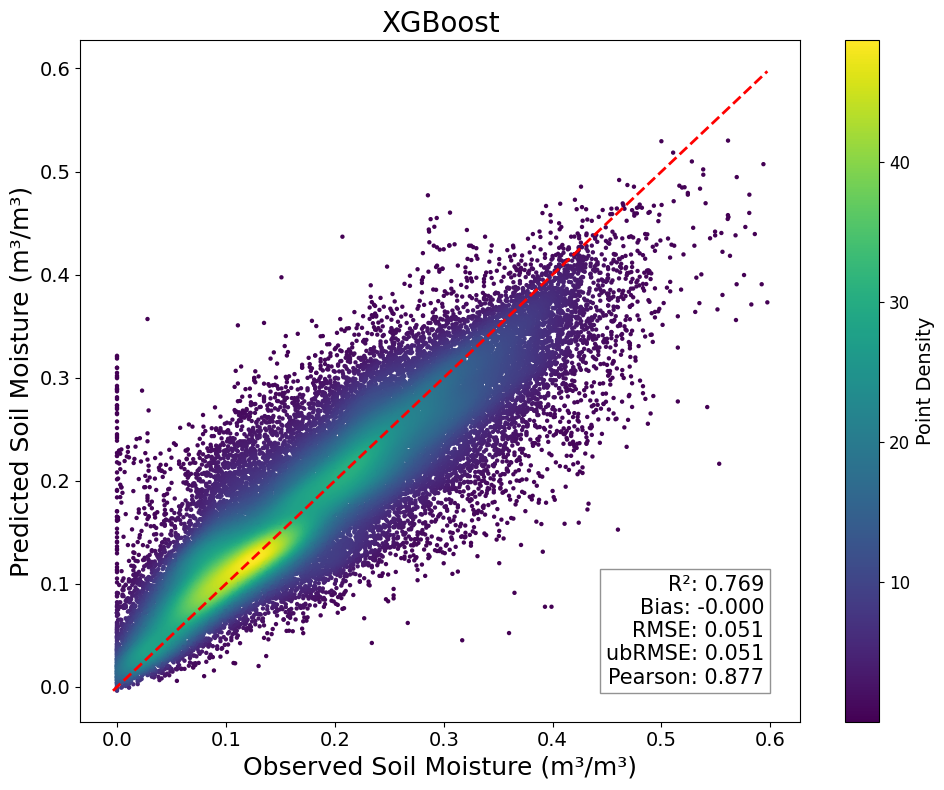


📊 Ensemble Model
R²:     0.6466
Bias:   -0.0168
RMSE:   0.0635
ubRMSE: 0.0612
Pearson:0.8904


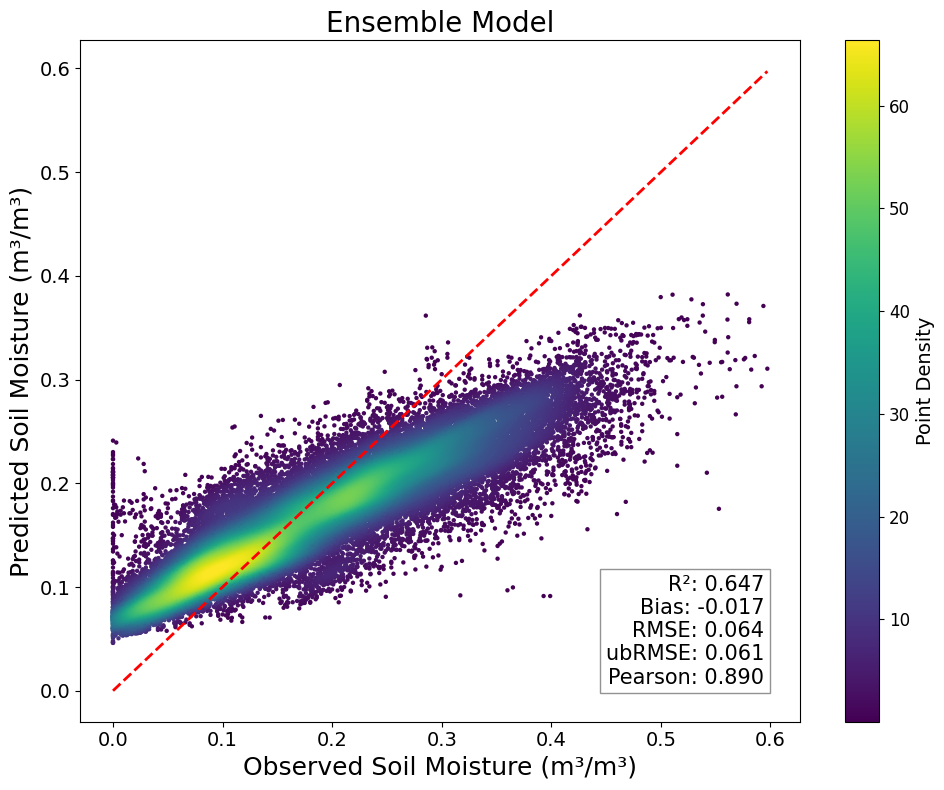

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import gaussian_kde, pearsonr

def evaluate_model(y_true, y_pred, model_name, max_points=100000):
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()

    # === Metrics ===
    r2 = r2_score(y_true, y_pred)
    error = y_pred - y_true
    bias = np.mean(error)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ubrmse = np.sqrt(np.mean((error - bias) ** 2))
    pearson, _ = pearsonr(y_true, y_pred)

    print(f"\n📊 {model_name}")
    print(f"R²:     {r2:.4f}")
    print(f"Bias:   {bias:.4f}")
    print(f"RMSE:   {rmse:.4f}")
    print(f"ubRMSE: {ubrmse:.4f}")
    print(f"Pearson:{pearson:.4f}")
    print("=" * 50)

    # === Subsample for KDE if needed ===
    if len(y_true) > max_points:
        idx = np.random.choice(len(y_true), max_points, replace=False)
        y_true_plot = y_true[idx]
        y_pred_plot = y_pred[idx]
    else:
        y_true_plot = y_true
        y_pred_plot = y_pred

    # === Density estimation ===
    xy = np.vstack([y_true_plot, y_pred_plot])
    z = gaussian_kde(xy)(xy)

    idx = z.argsort()
    x, y, z = y_true_plot[idx], y_pred_plot[idx], z[idx]

    # === Axis limits ===
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    # === Plot ===
    plt.figure(figsize=(10, 8))
    sc = plt.scatter(x, y, c=z, s=10, cmap='viridis', edgecolor='none')
    plt.plot([min_val, max_val], [min_val, max_val],
             'r--', lw=2, label='1:1 Line')

    # === Metrics box ===
    metrics_text = (
        f"R²: {r2:.3f}\n"
        f"Bias: {bias:.3f}\n"
        f"RMSE: {rmse:.3f}\n"
        f"ubRMSE: {ubrmse:.3f}\n"
        f"Pearson: {pearson:.3f}"
    )

    plt.text(
        0.95, 0.05, metrics_text,
        fontsize=15, ha='right', va='bottom',
        transform=plt.gca().transAxes,
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
    )

    # === Styling ===
    plt.xlabel("Observed Soil Moisture (m³/m³)", fontsize=18)
    plt.ylabel("Predicted Soil Moisture (m³/m³)", fontsize=18)
    plt.title(model_name, fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(False)

    cbar = plt.colorbar(sc)
    cbar.set_label("Point Density", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()
    plt.show()
evaluate_model(y_test, tabnet_preds_test, "TabNet")
evaluate_model(y_test, rf_preds_test, "Random Forest")
evaluate_model(y_test, xgb_preds_test, "XGBoost")
evaluate_model(y_test, ensemble_preds_test, "Ensemble Model")
